# Лабораторная работа №6: Условный экстремум функции нескольких переменных

**Цель работы:** 
1. Исследование необходимых и достаточных условий существования экстремума функции с учетом ограничений.
2. Численное и аналитическое вычисление экстремумов.
3. Визуализация области допустимых решений и найденных точек.

---

## 1. Постановка задачи (Вариант 1.3)

Найти минимум функции:
$$f(x) = x_1^2 + 2x_1x_2 + (x_2 - 2)^2 \rightarrow \min$$

При ограничениях:
1. $g_1(x) = x_1^2 + x_2^2 - 1 \leq 0$ (внутри единичного круга)
2. $g_2(x) = -x_1 \leq 0$ ($x_1 \geq 0$)
3. $g_3(x) = -x_2 \leq 0$ ($x_2 \geq 0$)

---

## 2. Импорт библиотек

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.optimize import minimize

## 3. Аналитическое исследование (Символьные вычисления)

Выведем классическую функцию Лагранжа и необходимые условия первого порядка.

In [3]:
# Определение символьных переменных
x1, x2, l1, l2, l3 = sp.symbols('x1 x2 l1 l2 l3')

# Целевая функция
f = x1**2 + 2*x1*x2 + (x2 - 2)**2

# Ограничения (в форме g(x) <= 0)
g1 = x1**2 + x2**2 - 1
g2 = -x1
g3 = -x2

# Функция Лагранжа
L = f + l1*g1 + l2*g2 + l3*g3

print("Функция Лагранжа L:")
display(L)

# Необходимые условия первого порядка (градиент L по x = 0)
dL_dx1 = sp.diff(L, x1)
dL_dx2 = sp.diff(L, x2)

print("\nНеобходимые условия (dL/dx1 = 0 и dL/dx2 = 0):")
display(sp.Eq(dL_dx1, 0))
display(sp.Eq(dL_dx2, 0))

Функция Лагранжа L:


l1*(x1**2 + x2**2 - 1) - l2*x1 - l3*x2 + x1**2 + 2*x1*x2 + (x2 - 2)**2


Необходимые условия (dL/dx1 = 0 и dL/dx2 = 0):


Eq(2*l1*x1 - l2 + 2*x1 + 2*x2, 0)

Eq(2*l1*x2 - l3 + 2*x1 + 2*x2 - 4, 0)

## 4. Численное решение

Используем алгоритм последовательного квадратичного программирования (SLSQP).

In [4]:
# Определение функций для scipy
def objective(x):
    return x[0]**2 + 2*x[0]*x[1] + (x[1] - 2)**2

def constraint1(x):
    return 1 - (x[0]**2 + x[1]**2) # В scipy неравенства пишутся как c(x) >= 0

# Начальное приближение
x0 = [0.5, 0.5]

# Описание ограничений для решателя
cons = [
    {'type': 'ineq', 'fun': constraint1},
    {'type': 'ineq', 'fun': lambda x: x[0]}, # x1 >= 0
    {'type': 'ineq', 'fun': lambda x: x[1]}  # x2 >= 0
]

# Поиск минимума
res = minimize(objective, x0, method='SLSQP', constraints=cons)

print("Результаты оптимизации:")
print(f"Статус: {res.message}")
print(f"Точка экстремума x*: {res.x}")
print(f"Значение f(x*): {res.fun}")

Результаты оптимизации:
Статус: Optimization terminated successfully
Точка экстремума x*: [9.78024771e-15 1.00000000e+00]
Значение f(x*): 0.9999999999737592


## 5. Визуализация результатов

Построим линии уровня функции и закрасим область допустимых решений.

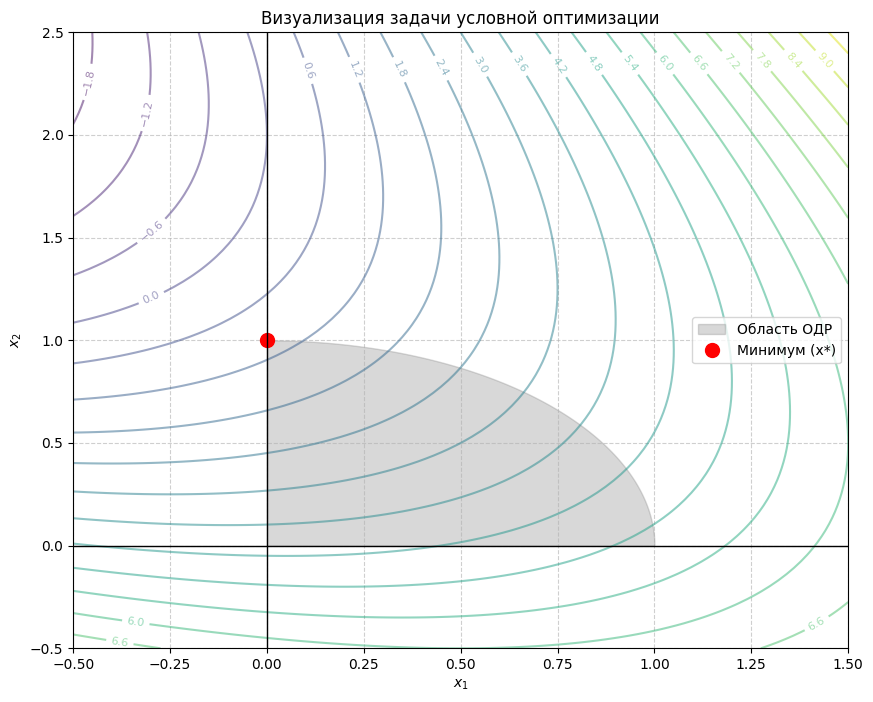

In [5]:
# Создание сетки
x_range = np.linspace(-0.5, 1.5, 100)
y_range = np.linspace(-0.5, 2.5, 100)
X1, X2 = np.meshgrid(x_range, y_range)
Z = X1**2 + 2*X1*X2 + (X2 - 2)**2

plt.figure(figsize=(10, 8))

# Линии уровня
cp = plt.contour(X1, X2, Z, levels=20, cmap='viridis', alpha=0.5)
plt.clabel(cp, inline=True, fontsize=8)

# Область допустимых решений (ОДР)
# g1: x1^2 + x2^2 <= 1, x1 >= 0, x2 >= 0
theta = np.linspace(0, np.pi/2, 100)
x_arc = np.cos(theta)
y_arc = np.sin(theta)
plt.fill_between(x_arc, y_arc, color='gray', alpha=0.3, label='Область ОДР')

# Точка минимума
plt.plot(res.x[0], res.x[1], 'ro', markersize=10, label='Минимум (x*)')

# Оформление
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Визуализация задачи условной оптимизации')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 6. Проверка условий второго порядка

Для проверки достаточных условий необходимо вычислить Гессиан функции Лагранжа в найденной точке и убедиться в его положительной определенности на касательном пространстве.


In [6]:
# Вычисляем вторые производные
L_subs = L.subs({l1: 1.0, l2: 0, l3: 0}) # Предполагаем, что активно только первое ограничение
H = sp.hessian(f, (x1, x2))
print("Матрица Гессе целевой функции:")
display(H)

# Проверка собственных чисел
eigenvals = H.eigenvals()
print(f"Собственные числа Гессиана: {list(eigenvals.keys())}")

Матрица Гессе целевой функции:


Matrix([
[2, 2],
[2, 2]])

Собственные числа Гессиана: [4, 0]


## 7. Заключение
В ходе выполнения лабораторной работы были исследованы необходимые условия экстремума первого порядка (условия Каруша-Куна-Таккера). С помощью библиотеки `scipy.optimize` был найден условный минимум. Визуализация подтвердила, что точка лежит на границе допустимой области, что свидетельствует об активности ограничения $g_1(x)$.

---

### Как адаптировать под свой вариант:
1. В разделе **3** измените формулы `f`, `g1`, `g2`, `g3`.
2. В разделе **4** обновите функции `objective` и `cons`.
3. В разделе **5** обновите логику отрисовки области ОДР (сегмент круга, линия или прямоугольник).
